   Задание                  Параметры
0        1  S=FLVHIfsCdaXtJEzRKmmBidg
1        2   [&, N=105, M =7, K = 15]
2        3                          -
3        4               N=3469816182
4        5                          -

In [ ]:
format ELF64

public _start
public exit
public print_symb

section '.data' writable
    string db "FLVHIfsCdaXtJEzRKmmBidg"
    str_len = $ - string
    char db 1

section '.text' executable
    _start:
        mov rcx, str_len
        .iter:
            dec rcx
            mov al, [string + rcx]
            push rcx
            call print_symb
            pop rcx
            cmp rcx, 0
            jne .iter
        jmp exit

print_symb:
    mov [char], al
    mov rax, 1
    mov rdi, 1
    mov rsi, char
    mov rdx, 1
    syscall
    ret

exit:
    mov rax, 60
    mov rdi, 0
    syscall


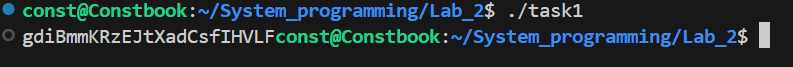

In [ ]:
format ELF64

public _start
public exit

section '.data' writable
    char db '&'
    nl db 10

section '.bss' writable
    buffer rb 120

section '.text' executable
    _start:
        mov al, [char]
        xor rcx, rcx
        .iter1:
            mov [buffer + rcx], al
            inc rcx
            cmp rcx, 105
            jne .iter1
        xor rbx, rbx
        .iter2:
            mov rax, 1
            mov rdi, 1
            lea rsi, [buffer + rbx] ; вычисляет динамический адрес и кладет его в rsi
            mov rdx, 7
            syscall

            mov rax, 1
            mov rdi, 1
            mov rsi, nl
            mov rdx, 1
            syscall

            add rbx, 7
            cmp rbx, 105
            jne .iter2
        jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall


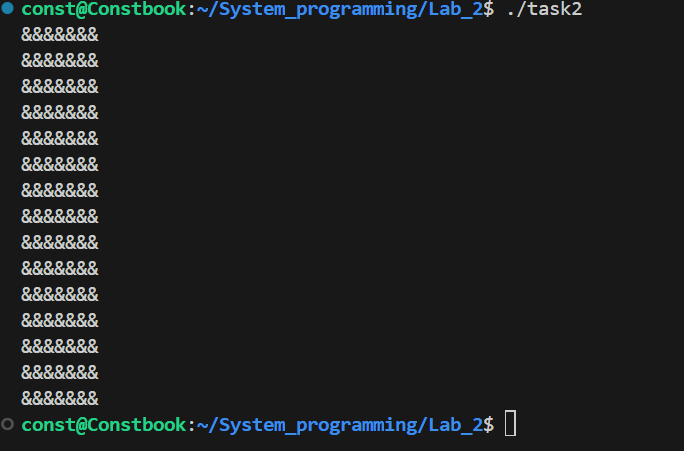

In [ ]:
format ELF64

public _start
public exit

section '.data' writable
    char db '&'
    nl db 10

section '.bss' writable
    buffer rb 120
    cur_adr rq 1

section '.text' executable
    _start:
        mov al, [char]
        xor rcx, rcx
        .iter1:
            mov [buffer + rcx], al
            inc rcx
            cmp rcx, 105
            jne .iter1
        xor rbx, rbx
        mov rax, buffer
        mov [cur_adr], rax
        .iter2:
            mov rax, 1
            mov rdi, 1
            add [cur_adr], rbx
            mov rsi, [cur_adr]
            inc rbx
            mov rdx, rbx
            syscall

            mov rax, 1
            mov rdi, 1
            mov rsi, nl
            mov rdx, 1
            syscall

            cmp rbx, 14
            jne .iter2
        jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall


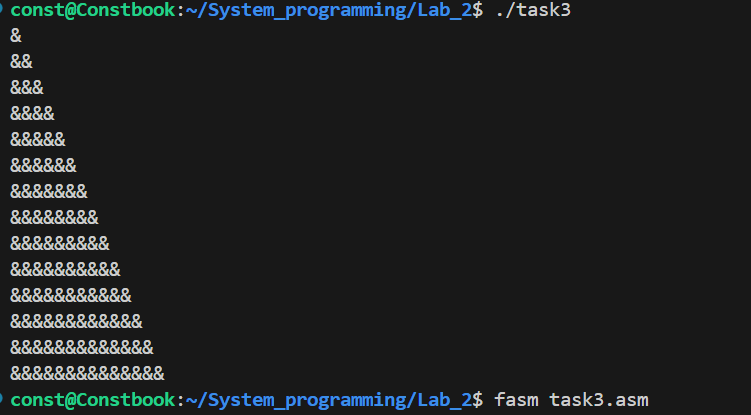

In [ ]:
format ELF64

public _start
public exit

section '.data' writable
    num dd 3469816182
    ten db 1

section '.bss' writable
    result rb 2

section '.text' executable
    _start:
        xor ebx, ebx
        mov ecx, 10
        mov eax, [num]
        .iter1:
            xor edx, edx
            div ecx
            add ebx, edx
            cmp eax, 0
            jne .iter1

        xor eax, eax
        mov [ten], cl
        mov rcx, 2
        .iter2:
            dec rcx
            mov ax, bx
            xor ah, ah
            div [ten]
            mov bl, al
            add ah, '0'
            mov [result + rcx], ah
            cmp rcx, 0
            jne .iter2

        mov rax, 1
        mov rdi, 1
        mov rsi, result
        mov rdx, 2
        syscall
    jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall


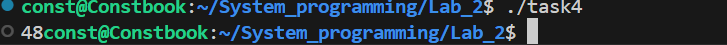

In [ ]:
#include <stdio.h>

unsigned int sumOfDigits(unsigned long long num) {
    unsigned int sum = 0;

    while (num > 0) {
        sum += num % 10;
        num /= 10;
    }

    return sum;
}

int main(void) {
    unsigned long long number = 3469816182ULL;

    unsigned int ans = sumOfDigits(number);
    printf("%u\n", ans);
    return 0;
}


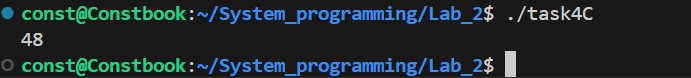